In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
np.random.seed(114514)

# 参数设置
shape = (100, 100, 100)  # 数据立方体的形状

mu_noise = 0.0  # 高斯噪声的均值
sigma_noise = 0.1  # 高斯噪声的标准差

num_spheres = 5  # 随机球形区域的个数
peak_value = 0.3  # 信号峰值
sigma_signal = 5  # 半高全宽对应的sigma

# 生成高斯噪声
data_3d = np.random.normal(mu_noise, sigma_noise, shape)

# 生成三维高斯峰信号
def generate_gaussian_peak(center, sigma, peak_value, shape):
    """
    生成一个三维高斯信号，球心为center，标准差为sigma，峰值为peak_value，在给定形状shape内
    """
    z, y, x = np.indices(shape)
    # 计算球心到每个点的距离平方
    distance_squared = (x - center[0])**2 + (y - center[1])**2 + (z - center[2])**2
    # 计算三维高斯分布
    gaussian = peak_value * np.exp(-distance_squared / (2 * sigma**2))
    return gaussian

'''
# 随机选取五个球形区域并填充信号
for _ in range(num_spheres):
    # 随机选择球形区域的中心
    center = np.random.randint(0, 100, size=3)
    # 生成三维高斯信号
    gaussian_signal = generate_gaussian_peak(center, sigma_signal, peak_value, shape)
    # 生成球形掩膜（半径 3σ）
    z, y, x = np.indices(shape)
    mask = (x - center[0])**2 + (y - center[1])**2 + (z - center[2])**2 <= (3 * sigma_signal)**2
    # 在掩膜区域内覆盖噪声，用高斯信号替换
    data_3d[mask] = gaussian_signal[mask]
'''
# 随机选取五个球形区域并填充信号
for _ in range(num_spheres):
    # 随机选择球形区域的中心
    center = np.random.randint(0, 100, size=3)
    # 生成三维高斯信号
    gaussian_signal = generate_gaussian_peak(center, sigma_signal, peak_value, shape)
    # 将信号添加到data_3d
    data_3d += gaussian_signal

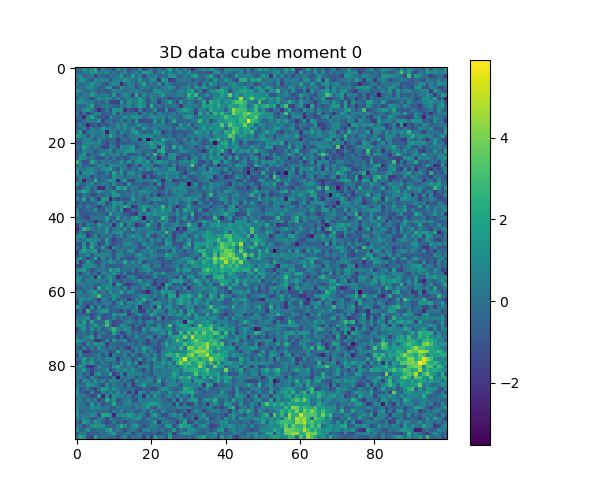

In [14]:
# 显示data_3d的切片
plt.figure(figsize=(6, 5))
plt.subplot(1, 1, 1)
plt.imshow(np.sum(data_3d, axis=0), cmap='viridis')
plt.colorbar()
plt.title("3D data cube moment 0")
plt.show()

Best value of x = 2.2
N(>xσ) / N(total) = 0.0148


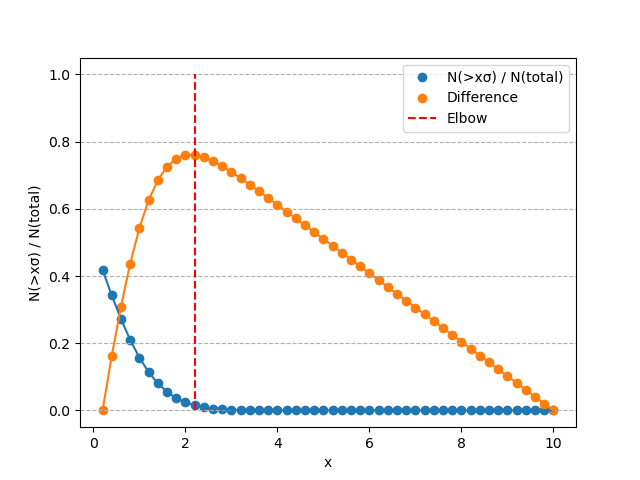

In [20]:
from kneed import KneeLocator

def test_sigma_clip(test=False):
    if test == True:
        # use knee/elbow value to find the best s value
        s_ = np.arange(0.2, 10.2, 0.2)
        y_ = []

        for i in range(len(s_)):
            upper_bound = data_3d.mean() + data_3d.std() * s_[i]
            mask = data_3d > upper_bound  # mask == True: v > sσ
            y_.append(
                np.count_nonzero(mask) / np.count_nonzero(data_3d)
            )  # N(True) / N(total)

        kneedle = KneeLocator(
            s_, y_, S=1.0, curve="convex", direction="decreasing"
        )  # knee/elbow value
        print("Best value of x =", round(kneedle.elbow, 4))
        print("N(>xσ) / N(total) =", round(kneedle.elbow_y, 4))

        # plot the results as in kneedle.plot_knee()
        plt.figure()
        plt.scatter(s_, y_, label="N(>xσ) / N(total)")
        plt.scatter(s_, kneedle.y_difference, label="Difference")
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 1.05)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red", label="Elbow")
        plt.xlabel("x")
        plt.ylabel("N(>xσ) / N(total)")
        plt.grid(axis="y", ls="--")
        plt.legend()
        plt.show()
        return kneedle.elbow
    else:
        # if (usually) the s value found this way is too small, choose s = 3
        return 3


s = test_sigma_clip(test=True)

In [16]:
# 将你一开始生成的spectrum一维数据，所有小于mu+2sigma的数据都设为NaN，得到spectrum_mask
data_3d_mask = data_3d.copy()
upper_bound = data_3d.mean() + data_3d.std() * s
print(upper_bound)
data_3d_mask[data_3d < upper_bound] = 0

0.22559728205868865


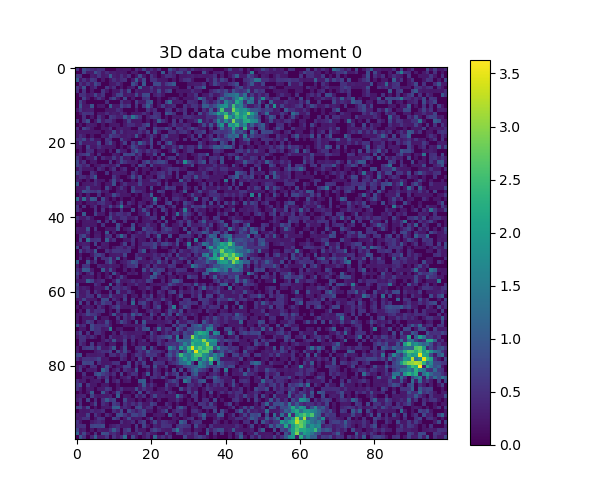

In [17]:
# 显示data_3d的切片
plt.figure(figsize=(6, 5))
plt.subplot(1, 1, 1)
plt.imshow(np.sum(data_3d_mask, axis=0), cmap='viridis')
plt.colorbar()
plt.title("3D data cube moment 0")
plt.show()

In [18]:
print(peak_value * sigma_signal**3 * (2*np.pi)**1.5)
print(np.sum(data_3d) / num_spheres)
print(np.sum(data_3d_mask) / num_spheres)

590.6103729645907
519.417342219925
787.7937995004854


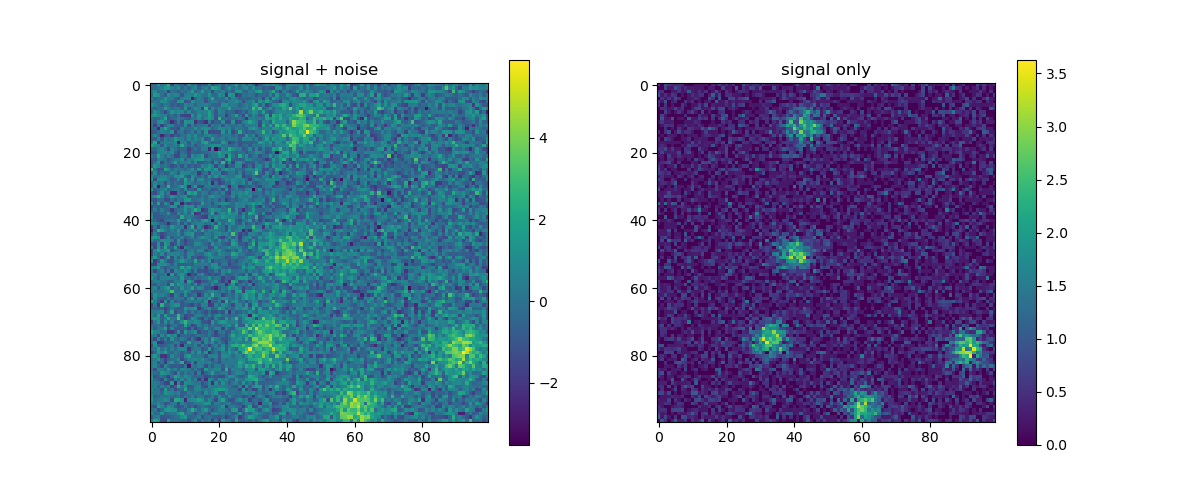

In [21]:
# 显示data_3d的切片
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.sum(data_3d, axis=0), cmap='viridis')
plt.colorbar()
plt.title("signal + noise")
plt.subplot(1, 2, 2)
plt.imshow(np.sum(data_3d_mask, axis=0), cmap='viridis')
plt.colorbar()
plt.title("signal only")
plt.show()